# Import Libraries

In [1]:
# ==========================================================
#  Imports and global configuration
# ==========================================================
import os
import warnings
import logging
import random
import copy
import shutil

import numpy as np
import pandas as pd

# Reproducible imports
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=Warning)

np.random.seed(SEED)
random.seed(SEED)

# ==========================================================
#  PyTorch
# ==========================================================
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device selection (MPS / CUDA / CPU)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {device}")

# ==========================================================
#  Metrics + data utilities
# ==========================================================
!mkdir -p models
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# ==========================================================
#  Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot

sns.set(font_scale=1.4)
sns.set_style("white")
plt.rc("font", size=14)

%matplotlib inline

Device: cuda


# Hyperparameters

In [2]:
# ==========================
# Training configuration
# ==========================
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 30  # Generic patience flag (kept for compatibility)

# ==========================
# Model architecture
# ==========================
HIDDEN_LAYERS = 2   # Number of LSTM layers
HIDDEN_SIZE = 64    # Hidden units per layer

# ==========================
# Regularisation
# ==========================
DROPOUT_RATE = 0.5  # Dropout probability
L1_LAMBDA = 0       # L1 penalty coefficient
L2_LAMBDA = 1e-4    # L2 penalty coefficient

# Separate early stopping patience used in training loop
EARLY_STOPPING_PATIENCE = 50

# ==========================
# Sliding window settings
# ==========================
WINDOW_SIZE = 40    # Window length (time steps)
WINDOW_STEP = 20    # Window stride (time steps)
N_WINDOWS = 0       # Will be set inside the K-fold loop

# ==========================
# CNN hyperparameters
# ==========================
CNN_FILTERS = 128       # Number of convolutional filters
CNN_KERNEL_SIZE = 5     # Kernel size (captures patterns over 5 time steps)
CNN_POOL_SIZE = 4       # Max-pooling size (reduces sequence length)

# ==========================
# Loss function
# ==========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


# Data

In [3]:
import random
import os

def seed_everything(seed=42):
    """
    Ensure full reproducibility across Python, NumPy, and PyTorch.
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

In [5]:
def build_sequences(df, feature_columns):
    """
    Build full-length time series per subject.

    Returns:
        dataset: np.array of shape (num_samples, 160, num_features)
        labels:  np.array of shape (num_samples,)
    """
    dataset = []
    labels = []

    # Iterate over subjects (sample_index)
    for sid in df["sample_index"].unique():
        # Select rows for this subject
        temp = df[df["sample_index"] == sid]

        # Sort by time
        temp = temp.sort_values("time")

        # Extract feature matrix
        seq = temp[feature_columns].values.astype(np.float32)

        # Sanity check: fixed length
        assert seq.shape[0] == 160, (
            f"sample_index={sid}: expected 160 steps, got {seq.shape[0]}"
        )

        dataset.append(seq)

        # Labels are available only for train/validation data
        if "label" in temp.columns:
            labels.append(label_mapping[temp["label"].values[0]])

    dataset = np.array(dataset)
    labels = np.array(labels) if len(labels) > 0 else None

    return dataset, labels


## Windows

In [6]:
def create_sliding_windows(X_full, y_full, window_size=80, step=20):
    """
    Create sliding windows from full sequences.

    Args:
        X_full: np.array of shape (num_samples, 160, num_features)
        y_full: np.array of shape (num_samples,)
        window_size: length of each extracted window
        step: stride between consecutive windows

    Returns:
        X_windows: np.array of shape (num_samples * n_windows, window_size, num_features)
        y_windows: np.array of shape (num_samples * n_windows,)
        n_windows_per_sample: number of windows generated per sequence
    """
    X_windows = []
    y_windows = []

    n_samples = X_full.shape[0]
    seq_len = X_full.shape[1]

    n_windows_per_sample = 0

    for i in range(n_samples):
        label = y_full[i]
        seq = X_full[i]

        for start in range(0, seq_len - window_size + 1, step):
            end = start + window_size

            X_windows.append(seq[start:end, :])
            y_windows.append(label)

            # Count number of windows only for the first sample
            if i == 0:
                n_windows_per_sample += 1

    print(f"  > Windows created per sequence: {n_windows_per_sample}")
    return np.array(X_windows), np.array(y_windows), n_windows_per_sample


## Data Augmentation

In [7]:
def augment_time_mask(seq, joint_indices, max_mask_perc=0.20, p_joint=0.5):
    """
    Apply temporal masking (Cutout) by zeroing out a contiguous time block
    for a random subset of joint features.

    Args:
        seq: input sequence of shape (window_len, num_features)
        joint_indices: list of indices corresponding to joint features
        max_mask_perc: maximum mask length as a percentage of window length
        p_joint: probability of masking each joint feature

    Returns:
        Augmented sequence with a masked temporal region.
    """
    seq_augmented = seq.copy()

    # Select joint columns to mask
    selected_indices = [idx for idx in joint_indices if np.random.rand() < p_joint]
    if not selected_indices:
        return seq

    seq_len = seq.shape[0]
    max_mask_len = max(1, int(seq_len * max_mask_perc))

    # Random mask length and start position
    mask_len = np.random.randint(1, max_mask_len + 1)
    start = np.random.randint(0, seq_len - mask_len + 1)

    # Apply mask
    mask_rows = np.arange(start, start + mask_len)
    seq_augmented[np.ix_(mask_rows, selected_indices)] = 0.0

    return seq_augmented


In [8]:
# =====================================================
# Data augmentation functions (joint features only)
# =====================================================

def augment_jitter(seq, joint_indices, sigma=0.01, p_joint=0.5):
    """
    Add small Gaussian noise to a random subset of joint feature columns.

    Args:
        seq: np.array (T, F) input sequence
        joint_indices: indices of joint-related features
        sigma: standard deviation of added noise
        p_joint: probability of augmenting each joint column

    Returns:
        Augmented sequence.
    """
    seq_augmented = seq.copy()
    selected_indices = [idx for idx in joint_indices if np.random.rand() < p_joint]

    if not selected_indices:
        return seq

    joint_data = seq_augmented[:, selected_indices]
    noise = np.random.normal(0, sigma, size=joint_data.shape)
    seq_augmented[:, selected_indices] = joint_data + noise

    return seq_augmented


def augment_scaling(seq, joint_indices, scale_range=(0.95, 1.05), p_joint=0.5):
    """
    Apply a global scaling factor to a random subset of joint feature columns.

    Args:
        seq: np.array (T, F) input sequence
        joint_indices: indices of joint-related features
        scale_range: range for uniform random scaling factor
        p_joint: probability of augmenting each joint column

    Returns:
        Augmented sequence.
    """
    seq_augmented = seq.copy()
    selected_indices = [idx for idx in joint_indices if np.random.rand() < p_joint]

    if not selected_indices:
        return seq

    joint_data = seq_augmented[:, selected_indices]
    scale = np.random.uniform(*scale_range)
    seq_augmented[:, selected_indices] = joint_data * scale

    return seq_augmented


def random_augment(seq, joint_indices, prob=0.8, force_augment=False):
    """
    Apply 0–2 random augmentations to the sequence.
    If force_augment is True, ensure at least one transformation is applied.

    Args:
        seq: np.array (T, F) input sequence
        joint_indices: indices of joint-related features
        prob: overall probability of applying augmentation
        force_augment: enforce at least one augmentation

    Returns:
        Augmented sequence.
    """
    if not force_augment and np.random.rand() > prob:
        return seq

    seq_aug = seq.copy()
    applied_any = False

    # Time masking (strongest augmentation)
    if np.random.rand() < 0.6:
        seq_aug = augment_time_mask(seq_aug, joint_indices)
        applied_any = True

    # Jitter (secondary augmentation)
    if np.random.rand() < 0.3:
        seq_aug = augment_jitter(seq_aug, joint_indices, sigma=0.005)
        applied_any = True

    # Optional scaling (disabled by design, kept for future flexibility)
    # if np.random.rand() < 0.1:
    #     seq_aug = augment_scaling(seq_aug, joint_indices)
    #     applied_any = True

    # Ensure at least one augmentation
    if force_augment and not applied_any:
        seq_aug = augment_time_mask(seq_aug, joint_indices)

    return seq_aug


In [9]:
# =====================================================
# Oversampling with augmentation (duplicates → augmented)
# =====================================================

def oversample_with_augmentation(X, y, joint_indices):
    """
    Perform class-balanced oversampling by:
      1. Keeping all original samples.
      2. Identifying the majority class size.
      3. Oversampling minority classes via sampling with replacement.
      4. Applying forced augmentation to each newly created sample.

    Args:
        X: array of shape (N, T, F)
        y: array of shape (N,)
        joint_indices: indices of joint-related features to augment

    Returns:
        X_new, y_new: oversampled and augmented dataset, shuffled.
    """
    unique_labels, counts = np.unique(y, return_counts=True)
    counts_dict = dict(zip(unique_labels, counts))

    # Determine majority class target count
    majority_label = unique_labels[np.argmax(counts)]
    target_n = counts_dict[majority_label]

    X_by_class = {label: X[y == label] for label in unique_labels}

    # Keep all original samples
    X_final_list = [X]
    y_final_list = [y]

    print(f"Oversampling from class counts {counts_dict} to {target_n} samples per class.")

    for label in unique_labels:
        if label == majority_label:
            continue

        n_current = counts_dict[label]
        n_to_add = target_n - n_current
        if n_to_add <= 0:
            continue

        print(f"Class {label}: adding {n_to_add} augmented samples.")

        # Sample with replacement within the minority class
        sample_indices = np.random.choice(n_current, n_to_add, replace=True)
        X_to_augment = X_by_class[label][sample_indices]

        # Apply forced augmentation to each new sample
        X_augmented_list = [
            random_augment(seq, joint_indices, force_augment=True)
            for seq in X_to_augment
        ]

        X_final_list.append(np.array(X_augmented_list))
        y_final_list.append(np.full(n_to_add, label))

    # Concatenate all data
    X_new = np.concatenate(X_final_list, axis=0)
    y_new = np.concatenate(y_final_list, axis=0)

    # Final shuffle
    idx = np.random.permutation(len(y_new))
    return X_new[idx], y_new[idx]


## Time Features

In [10]:
def add_time_features(df):
    """
    Add periodic time-encoding features (sin/cos) to each row.
    """
    # Convert time to periodic representation in the range [0, 2π]
    df["time_sin"] = np.sin(2 * np.pi * df["time"] / 160)
    df["time_cos"] = np.cos(2 * np.pi * df["time"] / 160)

    return df


## Convert in torch and loading

In [11]:
# @title
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 64

In [12]:
def make_loader(ds, batch_size=64, shuffle=False, drop_last=False):
    """
    Create a DataLoader with basic performance optimizations.

    Args:
        ds: TensorDataset
        batch_size: number of samples per batch
        shuffle: whether to shuffle the dataset
        drop_last: whether to drop the last incomplete batch

    Returns:
        A configured PyTorch DataLoader.
    """
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4
    )


# Model Building

In [13]:
def recurrent_summary(model, input_size):
    """
    Light summary function for RNN/GRU/LSTM-based models.
    Captures output shapes via forward hooks and prints parameter counts.

    Args:
        model (nn.Module): model to summarize
        input_size (tuple): (seq_len, features)
    """
    output_shapes = {}
    hooks = []

    def get_hook(name):
        """Create a forward hook to record output shapes."""
        def hook(module, inputs, outputs):
            # RNN/LSTM/GRU outputs are tuples
            if isinstance(outputs, tuple):
                # outputs[0]: sequence outputs
                seq_out = list(outputs[0].shape)
                seq_out[0] = -1  # replace batch dimension

                # outputs[1]: hidden state(s)
                hidden = outputs[1][0] if isinstance(outputs[1], tuple) else outputs[1]
                hid_out = list(hidden.shape)
                hid_out[1] = -1  # replace batch dimension

                output_shapes[name] = f"[{seq_out}, {hid_out}]"

            else:
                # Standard layer output
                out_shape = list(outputs.shape)
                out_shape[0] = -1
                output_shapes[name] = f"{out_shape}"
        return hook

    # Get model device
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")

    # Dummy input (batch_size = 1)
    dummy_input = torch.randn(1, *input_size).to(device)

    # Register hooks on direct child modules
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            hooks.append(module.register_forward_hook(get_hook(name)))

    # Forward pass
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            for h in hooks:
                h.remove()
            return

    # Remove hooks
    for h in hooks:
        h.remove()

    # Print table
    print("-" * 79)
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable = 0

    for name, module in model.named_children():
        if name in output_shapes:
            params = sum(p.numel() for p in module.parameters())
            trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += params
            total_trainable += trainable

            layer_name = f"{name} ({type(module).__name__})"
            print(f"{layer_name:<25} {output_shapes[name]:<28} {trainable:,}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable:,}")
    print(f"Non-trainable params: {total_params - total_trainable:,}")
    print("-" * 79)


# Training

In [14]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device,
                    l1_lambda=0, l2_lambda=0):
    """
    Train the model for one full epoch.

    Args:
        model: neural network model
        train_loader: DataLoader for training data
        criterion: loss function
        optimizer: optimizer instance
        scaler: GradScaler for mixed precision training
        device: computation device
        l1_lambda: L1 regularization strength
        l2_lambda: L2 regularization strength

    Returns:
        (epoch_loss, epoch_f1): average loss and weighted F1 for the epoch
    """
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with autocast for mixed precision (CUDA only)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass
        scaler.scale(loss).backward()

        # Unscale gradients before clipping
        scaler.unscale_(optimizer)

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1


In [16]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Evaluate the model for one full validation epoch.

    Args:
        model: neural network model
        val_loader: DataLoader for validation data
        criterion: loss function
        device: computation device

    Returns:
        (epoch_loss, epoch_f1): average loss and weighted F1 for the epoch
    """
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # Mixed precision for CUDA
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)

            preds = logits.argmax(dim=1)
            all_predictions.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1


In [17]:
import torch.nn.functional as F

def predict(model, loader, device):
    """
    Generate class probabilities for all samples in a DataLoader.

    Args:
        model: trained model
        loader: DataLoader containing data to predict
        device: computation device

    Returns:
        np.array of predicted probabilities for each sample.
    """
    model.eval()
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            # DataLoader returns (inputs, dummy_labels)
            inputs = batch[0].to(device, non_blocking=True)

            # Mixed precision on CUDA
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(inputs)
                probs = F.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())

    return np.concatenate(all_probs, axis=0)


In [18]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        scheduler, l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1",
        mode='max', restore_best_weights=True, writer=None, verbose=10,
        experiment_name=""):
    """
    Train the model and evaluate on the validation set.

    Args:
        model: neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        epochs: number of epochs
        criterion: loss function
        optimizer: optimizer instance
        scaler: GradScaler for mixed precision
        device: computation device
        scheduler: LR scheduler (optional)
        l1_lambda: L1 regularization strength
        l2_lambda: L2 regularization strength
        patience: early stopping patience
        evaluation_metric: metric tracked for early stopping
        mode: 'max' or 'min' for the metric direction
        restore_best_weights: reload best model after early stopping
        writer: TensorBoard SummaryWriter
        verbose: print frequency
        experiment_name: model save identifier

    Returns:
        model, training_history
    """

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs + 1):

        # Training pass
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler,
            device, l1_lambda, l2_lambda
        )

        # Validation pass
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Step LR scheduler on validation metric
        if scheduler:
            scheduler.step(val_f1)

        # Store metrics
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # TensorBoard logging
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Console logging
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}"
            )

        # Early stopping
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            improved = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if improved:
                best_metric = current_metric
                best_epoch = epoch

                checkpoint = {
                    'epoch': best_epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'training_history': training_history
                }

                torch.save(checkpoint, f"models/{experiment_name}_model.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best weights if early stopping was used
    if restore_best_weights and patience > 0:
        checkpoint = torch.load(f"models/{experiment_name}_model.pt",
                                map_location=device,
                                weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Best model restored from epoch {best_epoch} "
              f"with {evaluation_metric} = {best_metric:.4f}")

    # Save final model when early stopping is disabled
    if patience == 0:
        print("Saving model from final epoch (patience=0).")
        checkpoint = {
            'epoch': epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'training_history': training_history
        }
        torch.save(checkpoint, f"models/{experiment_name}_model.pt")

    if writer is not None:
        writer.close()

    return model, training_history


# CNN_LSTM_Attention

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM_Attention(nn.Module):
    """
    Hybrid model combining:
      - 1D CNN feature extractor
      - BiLSTM encoder
      - Attention mechanism
      - Final classification head
    """

    def __init__(self, input_channels: int, num_classes: int,
                 hidden_dim: int = 64, lstm_layers: int = 2, dropout: float = 0.3):
        super().__init__()

        # -------------------------------------------------
        # CNN feature extractor
        # -------------------------------------------------
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=1),

            nn.Dropout(dropout)
        )

        # -------------------------------------------------
        # BiLSTM encoder
        # -------------------------------------------------
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # -------------------------------------------------
        # Attention mechanism
        # -------------------------------------------------
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.attn_dropout = nn.Dropout(dropout)

        # -------------------------------------------------
        # Classification head
        # -------------------------------------------------
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        Args:
            x: tensor of shape (batch, time_steps, features)
        Returns:
            logits of shape (batch, num_classes)
        """
        # CNN expects (batch, channels, time)
        x = x.permute(0, 2, 1)

        # CNN feature extraction -> (batch, channels, time)
        cnn_out = self.cnn(x)

        # LSTM expects (batch, time, features)
        cnn_out = cnn_out.permute(0, 2, 1)

        # BiLSTM encoding
        lstm_out, _ = self.lstm(cnn_out)

        # Attention weights over time dimension
        attn_weights = F.softmax(self.attn(lstm_out), dim=1)

        # Weighted sum of hidden states
        attn_out = (lstm_out * attn_weights).sum(dim=1)
        attn_out = self.attn_dropout(attn_out)

        # Classification
        return self.fc(attn_out)


## K FOLD ENSEMBLING

In [20]:
from sklearn.model_selection import StratifiedKFold

# ==========================
# K-fold configuration
# ==========================
N_SPLITS = 7
KFOLD_SEED = 42

# ==========================
# Load raw data
# ==========================
X_train_forkfold = pd.read_csv('/kaggle/input/dataset/pirate_pain_train.csv')
y_train_forkfold = pd.read_csv('/kaggle/input/dataset/pirate_pain_train_labels.csv')
df_test_forkfold = pd.read_csv('/kaggle/input/dataset/pirate_pain_test.csv')

# Merge features and labels for training
df_train_full = X_train_forkfold.merge(y_train_forkfold, on='sample_index')
label_col = 'label'


In [21]:
# ==========================================================
# Global Feature Filtering (Joint Features Only)
# ==========================================================
from sklearn.feature_selection import mutual_info_classif

# Filtering parameters
LOW_VAR_THRESH = 1e-5      # Drop joints with variance below this threshold
MI_PERCENTILE = 10         # Drop bottom X% lowest-MI joints
MI_ABS_THRESH = 1e-3       # Drop joints with MI below this absolute threshold
CORR_THRESH = 0.95         # Drop one joint in each high-correlation (> threshold) pair
VERBOSE = True

# Feature groups
pain_cols  = [f"pain_survey_{i}" for i in range(1, 5)]
joint_cols = [f"joint_{i:02d}" for i in range(30)]
meta_cols  = ['n_legs', 'n_hands', 'n_eyes']

meta_map = {
        'two': 1.0, 'one+peg_leg': 0.0, 'one+hook_hand': 0.0, 'one+eye_patch': 0.0
    }

print("Starting global joint-feature filtering...")

# ----------------------------------------------------------
# 1) Low-variance filter
# ----------------------------------------------------------
joint_var = df_train_full[joint_cols].var()
low_var_cols = joint_var[joint_var < LOW_VAR_THRESH].index.tolist()

if VERBOSE:
    print(f"Low-variance joints (var < {LOW_VAR_THRESH}): {len(low_var_cols)} -> {low_var_cols}")

# ----------------------------------------------------------
# 2) Per-subject aggregated joint means (for MI + correlation)
# ----------------------------------------------------------
df_sample_joint_mean = (
    df_train_full
    .groupby("sample_index")[joint_cols]
    .mean()
    .reset_index(drop=True)
)

sample_labels = (
    df_train_full.groupby("sample_index")['label']
    .first()
    .map(label_mapping)
    .values
)

# ----------------------------------------------------------
# 3) Mutual Information filtering
# ----------------------------------------------------------
try:
    mi_vals = mutual_info_classif(
        df_sample_joint_mean.values,
        sample_labels,
        discrete_features=False,
        random_state=42
    )
except:
    # fallback for older sklearn versions
    mi_vals = mutual_info_classif(
        df_sample_joint_mean.values,
        sample_labels,
        discrete_features=False
    )

mi_series = pd.Series(mi_vals, index=joint_cols).sort_values()

n_drop_mi = max(1, int(len(mi_series) * (MI_PERCENTILE / 100)))
low_mi_cols_pct = mi_series.head(n_drop_mi).index.tolist()
low_mi_cols_abs = mi_series[mi_series < MI_ABS_THRESH].index.tolist()
low_mi_cols = sorted(set(low_mi_cols_pct + low_mi_cols_abs))

if VERBOSE:
    print(f"Mutual information: dropping {len(low_mi_cols)} joints "
          f"(bottom {MI_PERCENTILE}% or MI<{MI_ABS_THRESH}).")
    print("Lowest MI joints (examples):")
    print(mi_series.head(10))

# ----------------------------------------------------------
# 4) High-correlation filtering (retain the joint with highest MI)
# ----------------------------------------------------------
corr = df_sample_joint_mean.corr().abs()

to_drop_corr = set()
visited = set()

for col_i in joint_cols:
    if col_i in visited:
        continue

    correlated = [col for col in joint_cols
                  if col != col_i and corr.loc[col_i, col] > CORR_THRESH]

    if not correlated:
        visited.add(col_i)
        continue

    group = [col_i] + correlated
    group_sorted = sorted(group, key=lambda c: mi_series[c], reverse=True)

    keep = group_sorted[0]
    drop_candidates = group_sorted[1:]

    to_drop_corr.update(drop_candidates)
    visited.update(group)

if VERBOSE:
    print(f"Highly correlated joints dropped (corr > {CORR_THRESH}): {len(to_drop_corr)}")
    if len(to_drop_corr) > 0:
        print("Example:", list(to_drop_corr)[:10])

# ----------------------------------------------------------
# 5) Final filtering summary
# ----------------------------------------------------------
drops_all = set(low_var_cols) | set(low_mi_cols) | set(to_drop_corr)
kept_joints = [c for c in joint_cols if c not in drops_all]

print("\n=== Filtering summary ===")
print(f"Original joints      : {len(joint_cols)}")
print(f"Dropped (low-var)    : {len(low_var_cols)}")
print(f"Dropped (low-MI)     : {len(low_mi_cols)}")
print(f"Dropped (corr)       : {len(to_drop_corr)}")
print(f"Total dropped        : {len(drops_all)}")
print(f"Kept joint features  : {len(kept_joints)} -> {kept_joints}")

# ----------------------------------------------------------
# 6) Update training feature lists
# ----------------------------------------------------------
joint_cols = kept_joints
time_feature_cols = ['time_sin', 'time_cos']
feature_columns = pain_cols + joint_cols + meta_cols + time_feature_cols

# Indices of joint columns (used for augmentation)
JOINT_INDICES = [feature_columns.index(col) for col in joint_cols]

print("\nUpdated feature_columns length:", len(feature_columns))
print("JOINT_INDICES (len):", len(JOINT_INDICES))


Starting global joint-feature filtering...
Low-variance joints (var < 1e-05): 6 -> ['joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_23', 'joint_24']
Mutual information: dropping 3 joints (bottom 10% or MI<0.001).
Lowest MI joints (examples):
joint_01    0.019182
joint_25    0.022977
joint_12    0.028166
joint_10    0.033983
joint_06    0.040169
joint_00    0.046171
joint_05    0.047600
joint_08    0.048335
joint_19    0.064604
joint_20    0.065662
dtype: float64
Highly correlated joints dropped (corr > 0.95): 3
Example: ['joint_10', 'joint_15', 'joint_22']

=== Filtering summary ===
Original joints      : 30
Dropped (low-var)    : 6
Dropped (low-MI)     : 3
Dropped (corr)       : 3
Total dropped        : 11
Kept joint features  : 19 -> ['joint_00', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_11', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_26', 'joint_27', 'joint_28', 'joint_29']

Updated feature_c

In [22]:
# ==========================================================
# K-Fold Split (subject-level)
# ==========================================================
pirate_indices = df_train_full['sample_index'].unique()
pirate_labels = df_train_full.groupby('sample_index')[label_col].first()

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=KFOLD_SEED
)

all_test_preds = []
all_val_f1_scores = []
all_oof_preds = []  # Out-of-fold window-level probabilities
all_oof_true = []   # Out-of-fold true labels (subject-level)

# ==========================================================
# K-Fold Loop
# ==========================================================
for fold, (train_pos, val_pos) in enumerate(skf.split(pirate_indices, pirate_labels)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS} ---")

    # Subject IDs for this fold
    train_pirates = pirate_indices[train_pos]
    val_pirates = pirate_indices[val_pos]

    # Per-fold training/validation splits
    df_train_fold = df_train_full[df_train_full["sample_index"].isin(train_pirates)].copy()
    df_val_fold   = df_train_full[df_train_full["sample_index"].isin(val_pirates)].copy()
    df_test_fold  = df_test_forkfold.copy()

    # ------------------------------------------------------
    # Add time features
    # ------------------------------------------------------
    df_train_fold = add_time_features(df_train_fold)
    df_val_fold   = add_time_features(df_val_fold)
    df_test_fold  = add_time_features(df_test_fold)

    # ------------------------------------------------------
    # Z-score normalization (computed only on training fold)
    # ------------------------------------------------------
    means = df_train_fold[joint_cols].mean()
    stds  = df_train_fold[joint_cols].std()
    stds[stds < 1e-6] = 1.0  # avoid division by zero

    for df in [df_train_fold, df_val_fold, df_test_fold]:
        df[joint_cols] = (df[joint_cols] - means) / stds
        df[pain_cols] = df[pain_cols].astype(float) / 2.0
        for col in meta_cols:
            df[col] = df[col].map(meta_map)
        df[meta_cols] = df[meta_cols].fillna(1.0)

    # ------------------------------------------------------
    # Build full-length sequences
    # ------------------------------------------------------
    X_train_seq, y_train_seq = build_sequences(df_train_fold, feature_columns)
    X_val_seq,   y_val_seq   = build_sequences(df_val_fold,   feature_columns)
    X_test_seq, _            = build_sequences(df_test_fold,  feature_columns)

    # ------------------------------------------------------
    # Sliding window extraction
    # ------------------------------------------------------
    X_train_win, y_train_win, N_WINDOWS = create_sliding_windows(
        X_train_seq, y_train_seq, WINDOW_SIZE, WINDOW_STEP
    )
    X_val_win, y_val_win, _ = create_sliding_windows(
        X_val_seq, y_val_seq, WINDOW_SIZE, WINDOW_STEP
    )
    X_test_win, _, _ = create_sliding_windows(
        X_test_seq, np.zeros(len(X_test_seq)), WINDOW_SIZE, WINDOW_STEP
    )

    # ------------------------------------------------------
    # Oversampling + augmentation (train only)
    # ------------------------------------------------------
    X_train_aug, y_train_aug = oversample_with_augmentation(
        X_train_win,
        y_train_win,
        joint_indices=JOINT_INDICES
    )

    # ------------------------------------------------------
    # DataLoaders
    # ------------------------------------------------------
    train_ds = TensorDataset(
        torch.tensor(X_train_aug, dtype=torch.float32),
        torch.tensor(y_train_aug, dtype=torch.long)
    )
    val_ds = TensorDataset(
        torch.tensor(X_val_win, dtype=torch.float32),
        torch.tensor(y_val_win, dtype=torch.long)
    )

    y_test_dummy = np.zeros(len(X_test_win))
    test_ds = TensorDataset(
        torch.tensor(X_test_win, dtype=torch.float32),
        torch.tensor(y_test_dummy, dtype=torch.long)
    )

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    # ------------------------------------------------------
    # Model + training setup
    # ------------------------------------------------------
    seed_everything(KFOLD_SEED + fold)

    input_channels = X_train_win.shape[-1]
    num_classes = 3

    model = CNN_LSTM_Attention(
        input_channels=input_channels,
        num_classes=num_classes,
        hidden_dim=HIDDEN_SIZE,
        lstm_layers=HIDDEN_LAYERS,
        dropout=DROPOUT_RATE
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=3e-4
    )

    scheduler = ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=20, min_lr=1e-6
    )

    scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

    # ------------------------------------------------------
    # Train model
    # ------------------------------------------------------
    model, history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        scheduler=scheduler,
        device=device,
        l2_lambda=L2_LAMBDA,
        patience=EARLY_STOPPING_PATIENCE,
        verbose=50,
        experiment_name=f"kfold_pool_{fold}_v5.0"
    )

    all_val_f1_scores.append(np.max(history["val_f1"]))

    # ------------------------------------------------------
    # Save OOF predictions
    # ------------------------------------------------------
    all_oof_true.append(y_val_seq)  # subject-level true labels (pre-window)

    val_probs = predict(model, val_loader, device)  # window-level probabilities
    all_oof_preds.append(val_probs)

    # ------------------------------------------------------
    # Test-set predictions (window-level)
    # ------------------------------------------------------
    test_probs = predict(model, test_loader, device)
    all_test_preds.append(test_probs)

    print(f"--- End Fold {fold+1}, Val F1: {np.max(history['val_f1']):.4f} ---")

# ==========================================================
# Final summary
# ==========================================================
print("\n--- K-Fold Ensembling completed ---")
print(f"Mean validation F1 (OOF): {np.mean(all_val_f1_scores):.4f}")



--- FOLD 1/7 ---
  > Windows created per sequence: 7
  > Windows created per sequence: 7
  > Windows created per sequence: 7
Oversampling from class counts {0: 3066, 1: 560, 2: 336} to 3066 samples per class.
Class 1: adding 2506 augmented samples.
Class 2: adding 2730 augmented samples.
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7595, F1=0.7766 | Val: Loss=0.5734, F1=0.8746
Epoch  50/500 | Train: Loss=0.3550, F1=0.9912 | Val: Loss=0.4757, F1=0.9240
Early stopping triggered after 92 epochs.
Best model restored from epoch 42 with val_f1 = 0.9492
--- End Fold 1, Val F1: 0.9492 ---

--- FOLD 2/7 ---
  > Windows created per sequence: 7
  > Windows created per sequence: 7
  > Windows created per sequence: 7
Oversampling from class counts {0: 3066, 1: 560, 2: 336} to 3066 samples per class.
Class 1: adding 2506 augmented samples.
Class 2: adding 2730 augmented samples.
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7767, F1=0.7743 | Val: Loss=0.5064, F1=0.9010
Epoch  50/500 

# SUBMISSION + CONFUSION MATRIX

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_v2(y_true, y_pred, labels):
    """
    Plot a normalized confusion matrix (percentage-based).
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    cm_percent = cm * 100  # convert to percentages

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={'label': 'Percentage (%)'}
    )
    plt.title("Normalized Confusion Matrix (OOF)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

print("Function 'plot_confusion_matrix_v2' defined.")


Function 'plot_confusion_matrix_v2' defined.


Defined 'label_map_inv' for submission.

OOF Weighted F1 (subject-level): 0.9664


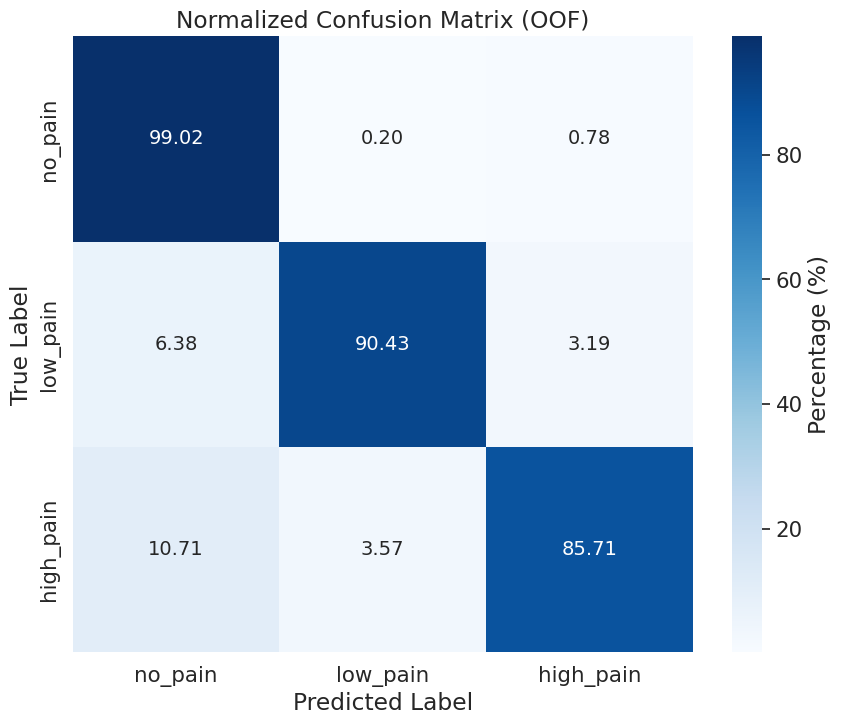

Submission file created: submission_f1_09664.csv

Final prediction distribution:
label
no_pain      0.782477
low_pain     0.141994
high_pain    0.075529
Name: proportion, dtype: float64


In [24]:
# ==========================================================
# Label mapping for submission
# ==========================================================
label_map_inv = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
print("Defined 'label_map_inv' for submission.")


# ==========================================================
# Out-of-Fold (OOF) Evaluation
# ==========================================================
try:
    # True subject-level labels (concatenated across folds)
    y_true_oof = np.concatenate(all_oof_true)       # (N_subjects,)
    
    # Window-level predicted probabilities
    y_probs_oof_window = np.concatenate(all_oof_preds)  # (N_subjects * N_WINDOWS, 3)

    # Reshape into (subjects, windows, classes)
    n_pirates_train = len(y_true_oof)
    y_probs_reshaped = y_probs_oof_window.reshape(n_pirates_train, N_WINDOWS, 3)

    # Aggregate by averaging over windows → subject-level probabilities
    y_probs_agg = np.mean(y_probs_reshaped, axis=1)  # (N_subjects, 3)

    # Save for stacking
    np.save("oof_train_features.npy", y_probs_agg)
    np.save("oof_train_labels.npy",  y_true_oof)

    # Final OOF predictions
    y_pred_oof = np.argmax(y_probs_agg, axis=1)

    # Compute OOF F1-score
    oof_f1 = f1_score(y_true_oof, y_pred_oof, average="weighted")
    print(f"\nOOF Weighted F1 (subject-level): {oof_f1:.4f}")

    # Plot confusion matrix
    plot_confusion_matrix_v2(
        y_true_oof,
        y_pred_oof,
        labels=list(label_map_inv.values())
    )

except Exception as e:
    print(f"OOF evaluation error: {e}")


# ==========================================================
# Submission Generation
# ==========================================================
try:
    # Stack predictions for all folds: (folds, windows*subjects, classes)
    preds_stack = np.stack(all_test_preds)
    avg_probs_window = np.mean(preds_stack, axis=0)  # (N_test_windows_total, 3)

    # Reshape into (subjects, windows, classes)
    n_pirates_test = len(df_test_forkfold["sample_index"].unique())
    avg_probs_reshaped = avg_probs_window.reshape(n_pirates_test, N_WINDOWS, 3)

    # Aggregate over windows
    avg_probs_agg = np.mean(avg_probs_reshaped, axis=1)  # (N_subjects_test, 3)

    # Save test stacking features
    np.save("oof_test_features.npy", avg_probs_agg)

    # Final predicted labels
    final_labels = np.argmax(avg_probs_agg, axis=1)

    # Retrieve sample indices
    test_sample_indices = df_test_forkfold["sample_index"].unique()

    if len(test_sample_indices) != len(final_labels):
        print(f"Shape mismatch: {len(test_sample_indices)} indices vs {len(final_labels)} predictions")

    # Build submission dataframe
    df_sub = pd.DataFrame({
        "sample_index": test_sample_indices,
        "label": final_labels
    })

    df_sub["label"] = df_sub["label"].map(label_map_inv)

    # Save submission
    val_f1_str = f"{oof_f1:.4f}".replace(".", "")
    submission_path = f"submission_f1_{val_f1_str}.csv"

    df_sub.to_csv(submission_path, index=False)
    print(f"Submission file created: {submission_path}")

    print("\nFinal prediction distribution:")
    print(df_sub["label"].value_counts(normalize=True))

except Exception as e:
    print(f"Submission error: {e}")


# Matplotlib

In [25]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

def plot_kfold_history_from_checkpoints(n_splits=7):
    """
    Load all K-fold checkpoint histories and plot training/validation
    F1-score and loss curves for each fold, including their averaged curves.
    """

    print("Loading checkpoints and generating plots...")

    fig_f1, ax_f1 = plt.subplots(figsize=(14, 9))
    fig_loss, ax_loss = plt.subplots(figsize=(14, 9))

    base_path = "models"

    # Lists to collect training curves for averaging
    all_train_f1s = []
    all_val_f1s = []
    all_train_losses = []
    all_val_losses = []
    max_epochs = 0  # used for padding different-length histories

    # ------------------------------------------------------
    # Load training histories for each fold
    # ------------------------------------------------------
    for fold in range(n_splits):

        experiment_name = f"kfold_pool_{fold}_v5.0"
        file_path = os.path.join(base_path, f"{experiment_name}_model.pt")

        try:
            checkpoint = torch.load(
                file_path,
                map_location='cpu',
                weights_only=False
            )

            history = checkpoint["training_history"]

            train_f1  = history["train_f1"]
            val_f1    = history["val_f1"]
            train_loss = history["train_loss"]
            val_loss   = history["val_loss"]

            # Store for fold-wise and averaged plotting
            all_train_f1s.append(train_f1)
            all_val_f1s.append(val_f1)
            all_train_losses.append(train_loss)
            all_val_losses.append(val_loss)

            max_epochs = max(max_epochs, len(train_f1))

            epochs = range(1, len(train_f1) + 1)
            color = plt.cm.jet(fold / n_splits)

            # Individual fold curves
            ax_f1.plot(epochs, train_f1, label=f"Fold {fold+1} Train",
                       color=color, alpha=0.3, linestyle=':')
            ax_f1.plot(epochs, val_f1, label=f"Fold {fold+1} Val",
                       color=color, alpha=0.5, linewidth=1.5)

            ax_loss.plot(epochs, train_loss, label=f"Fold {fold+1} Train",
                         color=color, alpha=0.3, linestyle=':')
            ax_loss.plot(epochs, val_loss, label=f"Fold {fold+1} Val",
                         color=color, alpha=0.5, linewidth=1.5)

        except FileNotFoundError:
            print(f"Warning: checkpoint not found: {file_path}. Skipping fold {fold+1}.")
        except KeyError:
            print(f"Error: 'training_history' missing in {file_path}.")
        except Exception as e:
            print(f"Error loading fold {fold+1}: {e}")

    # ------------------------------------------------------
    # Averaged curves (handling early stopping length differences)
    # ------------------------------------------------------
    def _pad_histories(histories, max_len):
        """Pad variable-length histories with NaN for averaging."""
        padded = []
        for h in histories:
            arr = np.full(max_len, np.nan)
            arr[:len(h)] = h
            padded.append(arr)
        return np.array(padded)

    if max_epochs > 0:
        padded_train_f1s  = _pad_histories(all_train_f1s, max_epochs)
        padded_val_f1s    = _pad_histories(all_val_f1s, max_epochs)
        padded_train_loss = _pad_histories(all_train_losses, max_epochs)
        padded_val_loss   = _pad_histories(all_val_losses, max_epochs)

        mean_train_f1  = np.nanmean(padded_train_f1s,  axis=0)
        mean_val_f1    = np.nanmean(padded_val_f1s,    axis=0)
        mean_train_loss = np.nanmean(padded_train_loss, axis=0)
        mean_val_loss   = np.nanmean(padded_val_loss,   axis=0)

        epoch_range = range(1, max_epochs + 1)

        # Averaged curves (bold)
        ax_f1.plot(epoch_range, mean_train_f1, label="Mean Train",
                   color="black", linestyle=':', linewidth=3, zorder=10)
        ax_f1.plot(epoch_range, mean_val_f1, label="Mean Val",
                   color="black", linewidth=4, zorder=10)

        ax_loss.plot(epoch_range, mean_train_loss, label="Mean Train",
                     color="black", linestyle=':', linewidth=3, zorder=10)
        ax_loss.plot(epoch_range, mean_val_loss, label="Mean Val",
                     color="black", linewidth=4, zorder=10)

    # ------------------------------------------------------
    # Plot formatting
    # ------------------------------------------------------
    ax_f1.set_title("F1 Score History (All Folds)", fontsize=16)
    ax_f1.set_xlabel("Epoch", fontsize=12)
    ax_f1.set_ylabel("Weighted F1 Score", fontsize=12)
    ax_f1.legend(loc="lower right", fontsize="small", ncol=2)
    ax_f1.grid(True, linestyle=':', alpha=0.6)

    ax_loss.set_title("Loss History (All Folds)", fontsize=16)
    ax_loss.set_xlabel("Epoch", fontsize=12)
    ax_loss.set_ylabel("Loss", fontsize=12)
    ax_loss.legend(loc="upper right", fontsize="small", ncol=2)
    ax_loss.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


print("Function 'plot_kfold_history_from_checkpoints' defined.")


Function 'plot_kfold_history_from_checkpoints' defined.


Loading checkpoints and generating plots...


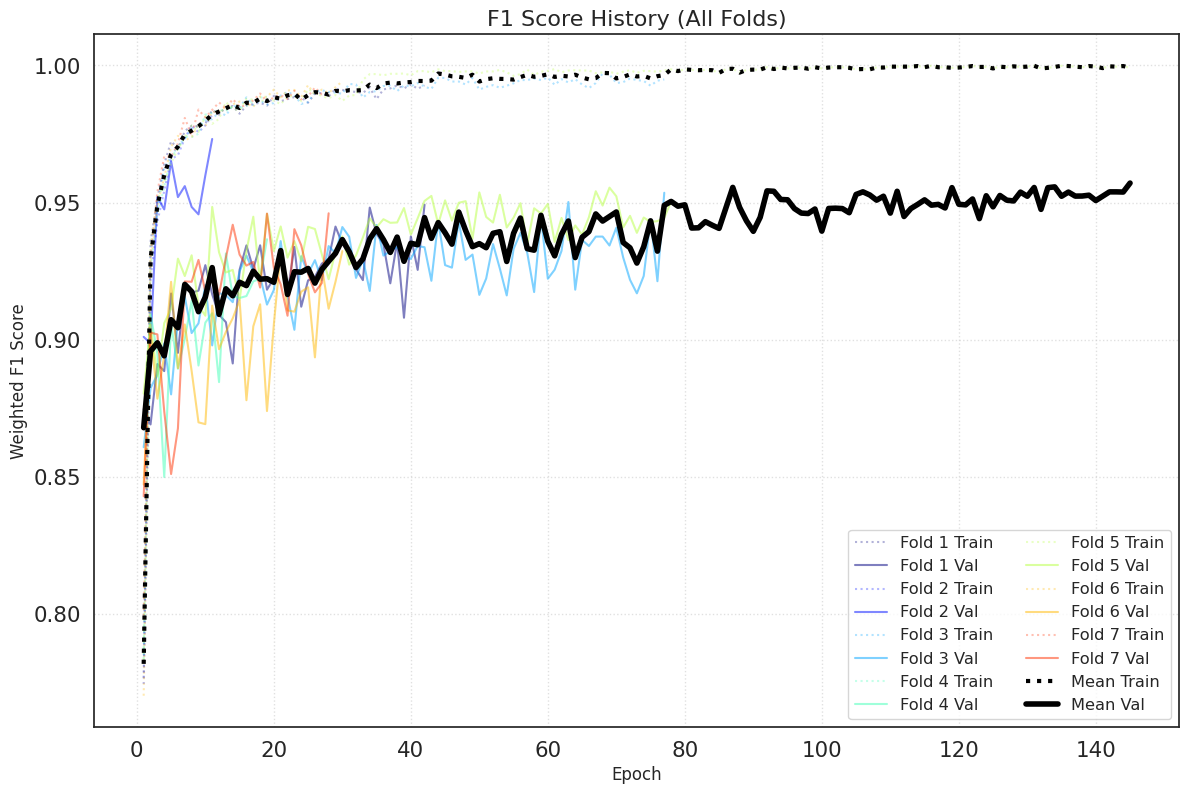

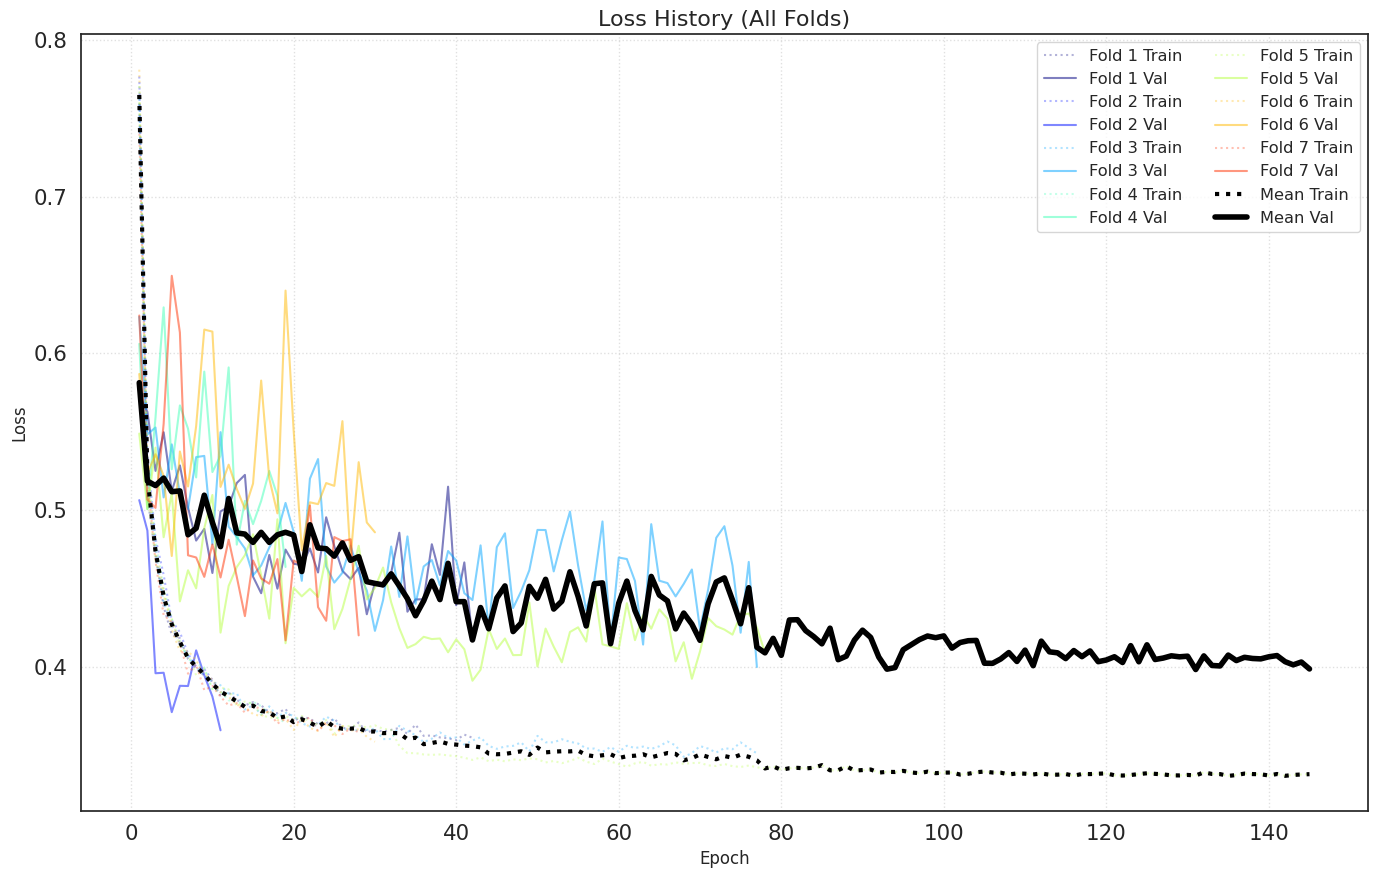

In [26]:
# ==========================================================
# Execute K-fold history plotting
# ==========================================================
try:
    plot_kfold_history_from_checkpoints(n_splits=N_SPLITS)
except NameError:
    print("Error: 'N_SPLITS' is not defined. Ensure the previous cells were executed.")
except Exception as e:
    print(f"Plotting error: {e}")
